#  Modèle CNN - Reconnaissance Tifinagh MNIST
Entraînement d'un réseau de neurones convolutifs (CNN) pour la classification de caractères Tifinagh.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import os


In [9]:

# ─── 1. CHARGEMENT DES DONNÉES PRÉTRAITÉES ────────────────
X_train = np.load("../data/X_train.npy")
X_val   = np.load("../data/X_val.npy")
X_test  = np.load("../data/X_test.npy")
y_train = np.load("../data/y_train.npy")
y_val   = np.load("../data/y_val.npy")
y_test  = np.load("../data/y_test.npy")

print(f"Train : {X_train.shape} | Val : {X_val.shape} | Test : {X_test.shape}")


Train : (46226, 28, 28, 1) | Val : (9874, 28, 28, 1) | Test : (9900, 28, 28, 1)


In [10]:

# ─── 2. ARCHITECTURE CNN ──────────────────────────────────
model = Sequential([
    # Bloc 1
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28,28,1)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Bloc 2
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Bloc 3
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Classificateur
    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(33, activation='softmax')  # 33 classes Tifinagh
])

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 33)             │         8,481 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 444,801 (1.70 MB)

 Trainable params: 443,649 (1.69 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [11]:

# ─── 3. COMPILATION ───────────────────────────────────────
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [12]:

# ─── 4. CALLBACKS ─────────────────────────────────────────
os.makedirs("../results/models", exist_ok=True)

callbacks = [
    # Arrêt si pas d'amélioration pendant 5 epochs
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    
    # Sauvegarde du meilleur modèle
    ModelCheckpoint("../results/models/best_model.h5", monitor='val_accuracy',
                    save_best_only=True, verbose=1),
    
    # Réduction du learning rate si plateau
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-6)
]


In [13]:

# ─── 5. ENTRAÎNEMENT ──────────────────────────────────────
print("\n Entraînement en cours...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)




 Entraînement en cours...
Epoch 1/30
723/723 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.7595 - loss: 0.9290
Epoch 1: val_accuracy improved from None to 0.99777, saving model to ../results/models/best_model.h5



Epoch 1: finished saving model to ../results/models/best_model.h5
723/723 ━━━━━━━━━━━━━━━━━━━━ 116s 149ms/step - accuracy: 0.9173 - loss: 0.3102 - val_accuracy: 0.9978 - val_loss: 0.0085 - learning_rate: 0.0010
Epoch 2/30
723/723 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.9964 - loss: 0.0192
Epoch 2: val_accuracy improved from 0.99777 to 0.99949, saving model to ../results/models/best_model.h5



Epoch 2: finished saving model to ../results/models/best_model.h5
723/723 ━━━━━━━━━━━━━━━━━━━━ 122s 169ms/step - accuracy: 0.9974 - loss: 0.0148 - val_accuracy: 0.9995 - val_loss: 0.0019 - learning_rate: 0.0010
Epoch 3/30
723/723 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.9984 - loss: 0.0086
Epoch 3: val_accuracy improved from 0.99949 to 0.99980, saving model to ../results/models/best_model.h5



Epoch 3: finished saving model to ../results/models/best_model.h5
723/723 ━━━━━━━━━━━━━━━━━━━━ 112s 154ms/step - accuracy: 0.9988 - loss: 0.0075 - val_accuracy: 0.9998 - val_loss: 5.2354e-04 - learning_rate: 0.0010
Epoch 4/30
723/723 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.9987 - loss: 0.0066
Epoch 4: val_accuracy did not improve from 0.99980
723/723 ━━━━━━━━━━━━━━━━━━━━ 107s 147ms/step - accuracy: 0.9986 - loss: 0.0068 - val_accuracy: 0.9996 - val_loss: 6.7152e-04 - learning_rate: 0.0010
Epoch 5/30
723/723 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.9991 - loss: 0.0044
Epoch 5: val_accuracy did not improve from 0.99980
723/723 ━━━━━━━━━━━━━━━━━━━━ 109s 151ms/step - accuracy: 0.9990 - loss: 0.0050 - val_accuracy: 0.9995 - val_loss: 0.0013 - learning_rate: 0.0010
Epoch 6/30
722/723 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.9987 - loss: 0.0055
Epoch 6: val_accuracy did not improve from 0.99980

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.00050000002374872


Epoch 7: finished saving model to ../results/models/best_model.h5
723/723 ━━━━━━━━━━━━━━━━━━━━ 87s 120ms/step - accuracy: 0.9993 - loss: 0.0036 - val_accuracy: 1.0000 - val_loss: 1.8748e-04 - learning_rate: 5.0000e-04
Epoch 8/30
722/723 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.9997 - loss: 0.0023
Epoch 8: val_accuracy did not improve from 1.00000
723/723 ━━━━━━━━━━━━━━━━━━━━ 91s 125ms/step - accuracy: 0.9997 - loss: 0.0021 - val_accuracy: 1.0000 - val_loss: 1.2734e-04 - learning_rate: 5.0000e-04
Epoch 9/30
723/723 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.9997 - loss: 0.0018
Epoch 9: val_accuracy did not improve from 1.00000
723/723 ━━━━━━━━━━━━━━━━━━━━ 91s 125ms/step - accuracy: 0.9997 - loss: 0.0019 - val_accuracy: 1.0000 - val_loss: 1.8797e-04 - learning_rate: 5.0000e-04
Epoch 10/30
723/723 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.9994 - loss: 0.0027
Epoch 10: val_accuracy did not improve from 1.00000

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0

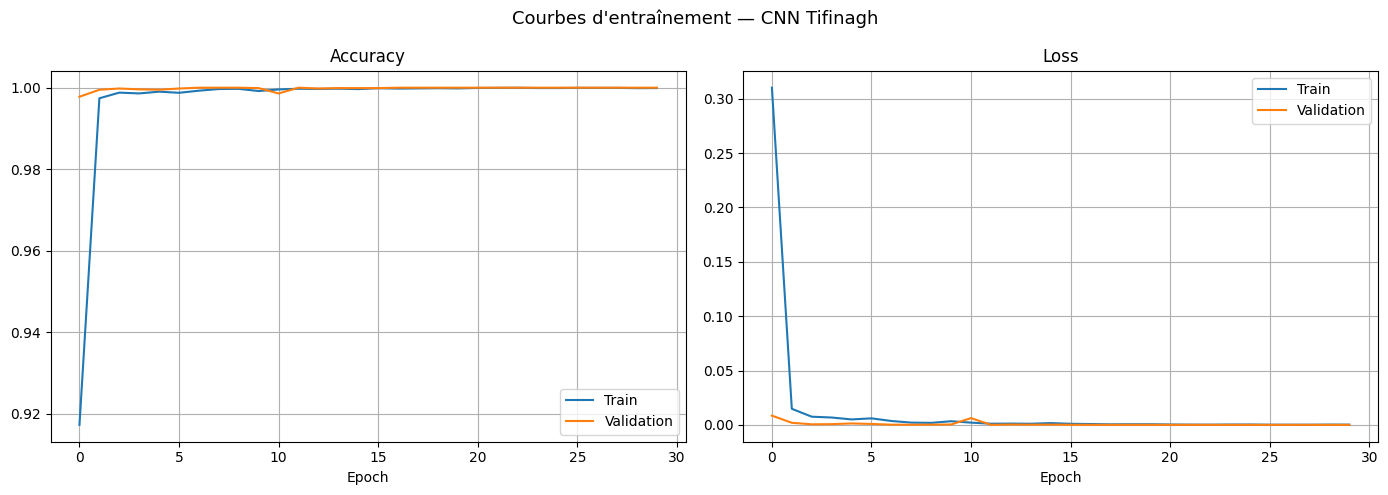

In [14]:
# ─── 6. COURBES D'APPRENTISSAGE ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)

plt.suptitle("Courbes d'entraînement — CNN Tifinagh", fontsize=13)
plt.tight_layout()
plt.savefig("../results/figures/courbes_entrainement.png")
plt.show()


In [15]:

# ─── 7. ÉVALUATION SUR LE TEST ────────────────────────────
print("\n Évaluation sur le set de test :")
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy : {test_acc*100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")



 Évaluation sur le set de test :
Test Accuracy : 100.00%
Test Loss     : 0.0000


In [19]:

# ─── 8. RAPPORT DE CLASSIFICATION ────────────────────────
tifinagh_mapping = [
    'ⴰ','ⴱ','ⵛ','ⴷ','ⴻ','ⴼ','ⴳ',
    'ⵀ','ⵉ','ⵊ','ⴽ','ⵍ','ⵎ','ⵏ','ⵇ',
    'ⵔ','ⵙ','ⵜ','ⵓ','ⵡ','ⵢ','ⵅ','ⵣ','ⵃ','ⵚ','ⴹ','ⵟ',
    'ⵄ','ⵖ','ⵥ','ⴳⵯ','ⴽⵯ','ⵕ',
    
]

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

print("\n Rapport de classification :")
print(classification_report(y_true_classes, y_pred_classes, target_names=tifinagh_mapping))


310/310 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step

 Rapport de classification :
              precision    recall  f1-score   support

           ⴰ       1.00      1.00      1.00       300
           ⴱ       1.00      1.00      1.00       300
           ⵛ       1.00      1.00      1.00       300
           ⴷ       1.00      1.00      1.00       300
           ⴻ       1.00      1.00      1.00       300
           ⴼ       1.00      1.00      1.00       300
           ⴳ       1.00      1.00      1.00       300
           ⵀ       1.00      1.00      1.00       300
           ⵉ       1.00      1.00      1.00       300
           ⵊ       1.00      1.00      1.00       300
           ⴽ       1.00      1.00      1.00       300
           ⵍ       1.00      1.00      1.00       300
           ⵎ       1.00      1.00      1.00       300
           ⵏ       1.00      1.00      1.00       300
           ⵇ       1.00      1.00      1.00       300
           ⵔ       1.00      1.00      1.00       300
         

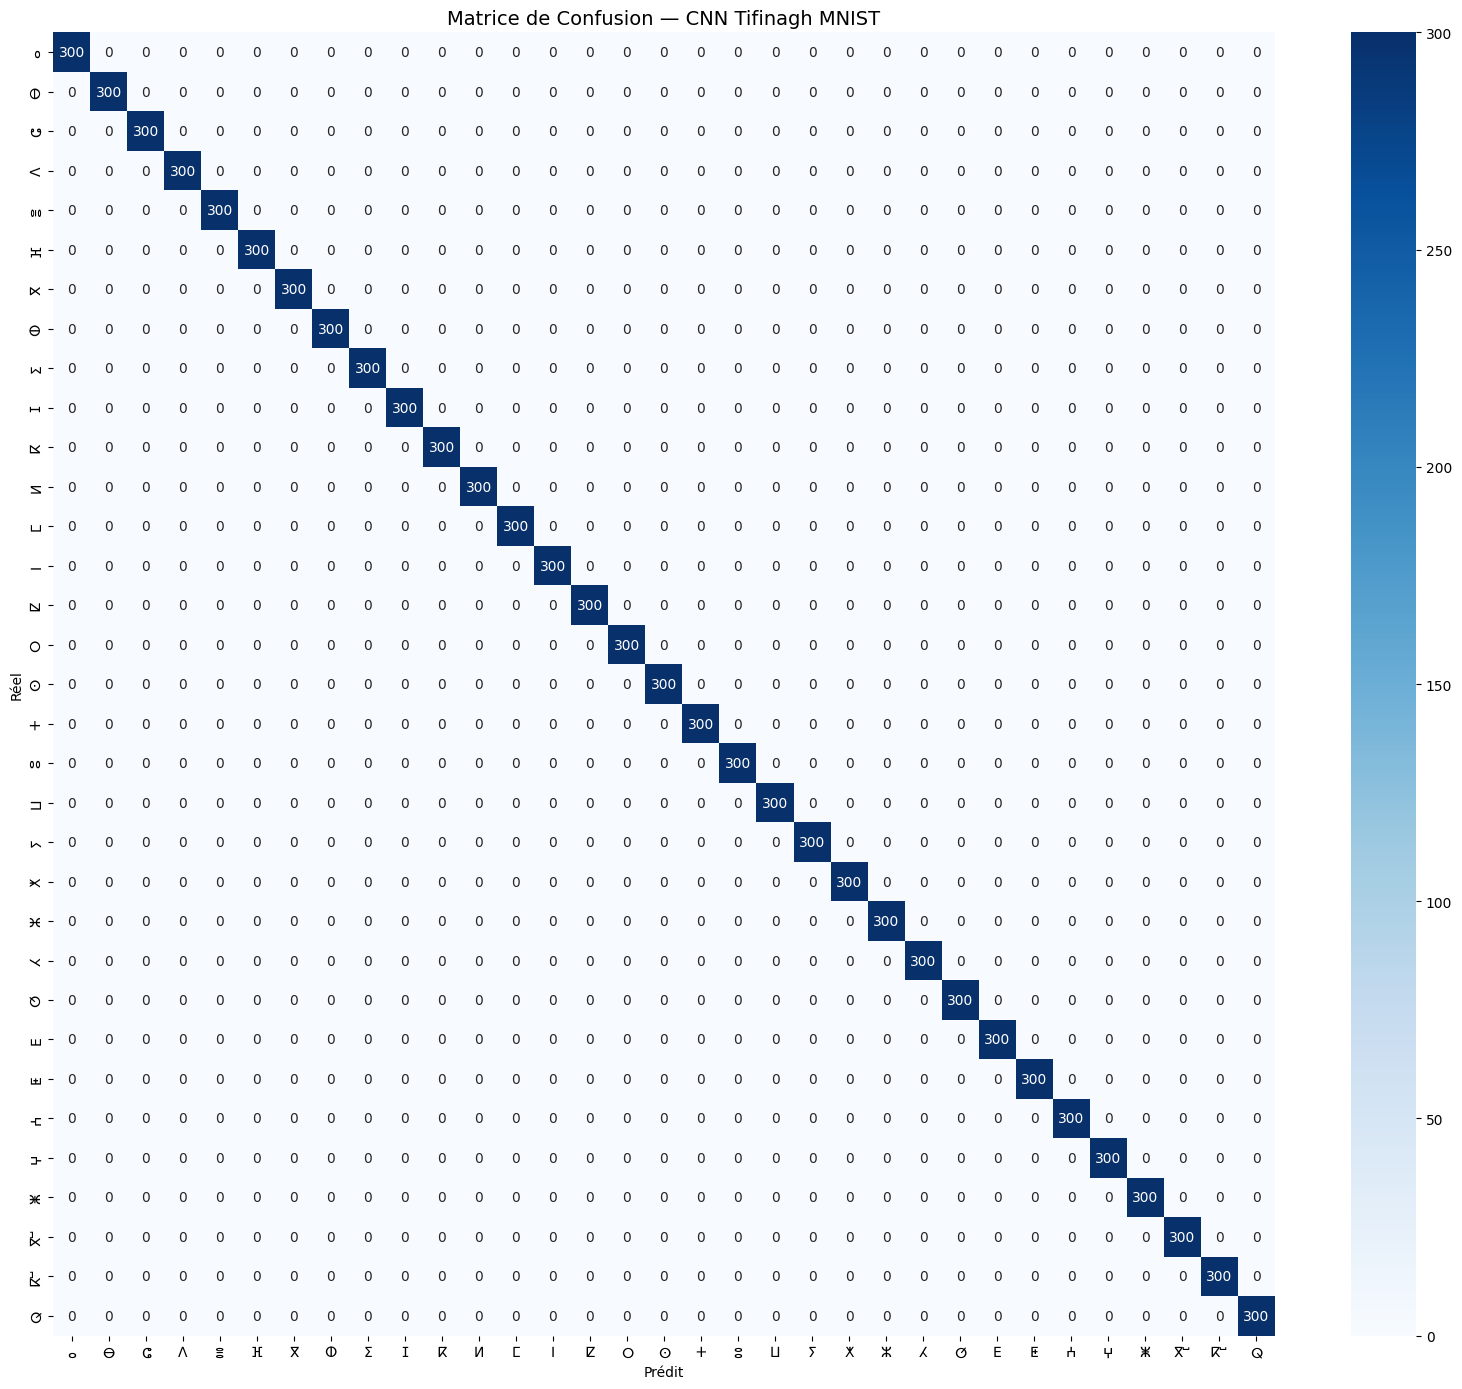

In [20]:

# ─── 9. MATRICE DE CONFUSION ──────────────────────────────
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=tifinagh_mapping,
            yticklabels=tifinagh_mapping)
plt.title("Matrice de Confusion — CNN Tifinagh MNIST", fontsize=14)
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.tight_layout()
plt.savefig("../results/figures/matrice_confusion.png")
plt.show()


In [21]:

# ─── 10. SAUVEGARDE FINALE ────────────────────────────────
model.save("../results/models/cnn_tifinagh_final.h5")
print("\n Modèle sauvegardé dans results/models/")


 Modèle sauvegardé dans results/models/
